In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import re
import string

In [2]:
data=pd.read_csv("housing.csv")

In [3]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
data.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
data.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [6]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
data.dropna(inplace=True)


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [9]:
x=data.drop(['median_house_value'], axis=1)
y=data['median_house_value']

In [10]:
x_train, x_test, y_train, y_test= train_test_split(x , y, test_size=0.2)

In [11]:
train_data= x_train.join(y_train)

In [12]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
13696,-117.20,34.13,14.0,3998.0,711.0,1509.0,665.0,3.4138,INLAND,126700.0
14787,-117.13,32.58,27.0,2511.0,615.0,1427.0,576.0,3.1645,NEAR OCEAN,156000.0
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN,112500.0
19141,-122.70,38.33,16.0,1244.0,242.0,696.0,236.0,3.6369,<1H OCEAN,158700.0
8150,-118.09,33.81,36.0,1878.0,323.0,846.0,325.0,7.1937,<1H OCEAN,254400.0
...,...,...,...,...,...,...,...,...,...,...
20297,-119.22,34.15,32.0,3152.0,596.0,3490.0,526.0,2.7250,NEAR OCEAN,450000.0
2649,-124.10,40.50,42.0,2380.0,553.0,1300.0,504.0,1.7574,<1H OCEAN,57500.0
10486,-117.68,33.48,15.0,1786.0,299.0,727.0,293.0,5.0527,<1H OCEAN,231400.0
20360,-118.94,34.17,16.0,3746.0,508.0,1556.0,452.0,6.3303,<1H OCEAN,299400.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

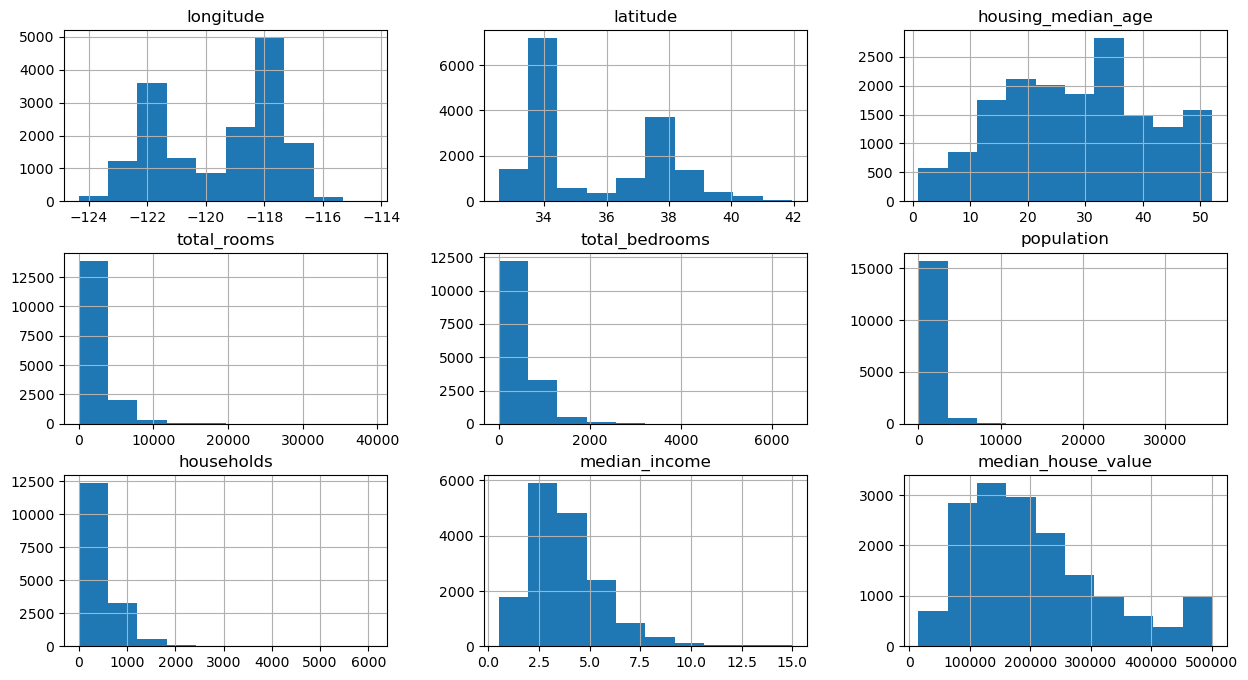

In [13]:
train_data.hist(figsize=(15,8))

<Axes: >

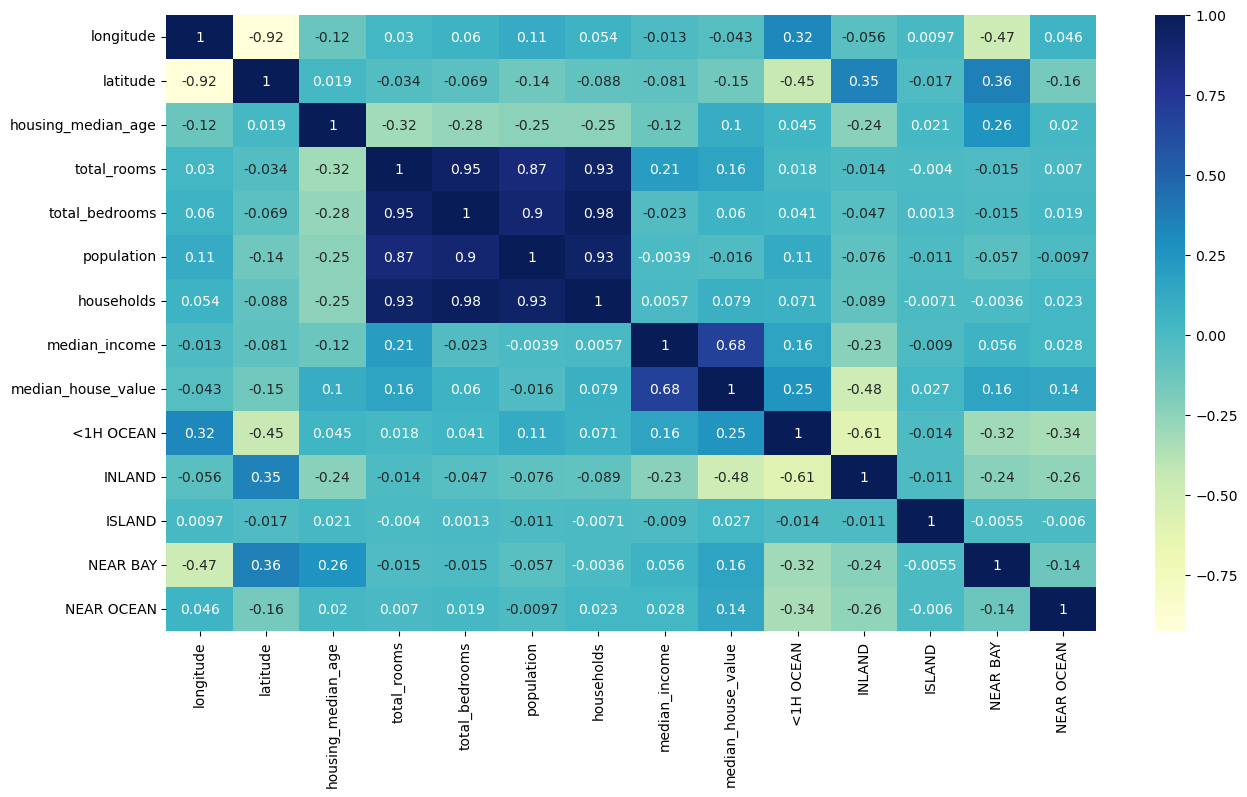

In [21]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap='YlGnBu')

In [15]:
train_data['total_rooms']=np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms']=np.log(train_data['total_bedrooms'] + 1)
train_data['population']=np.log(train_data['population'] + 1)
train_data['households']=np.log(train_data['households'] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

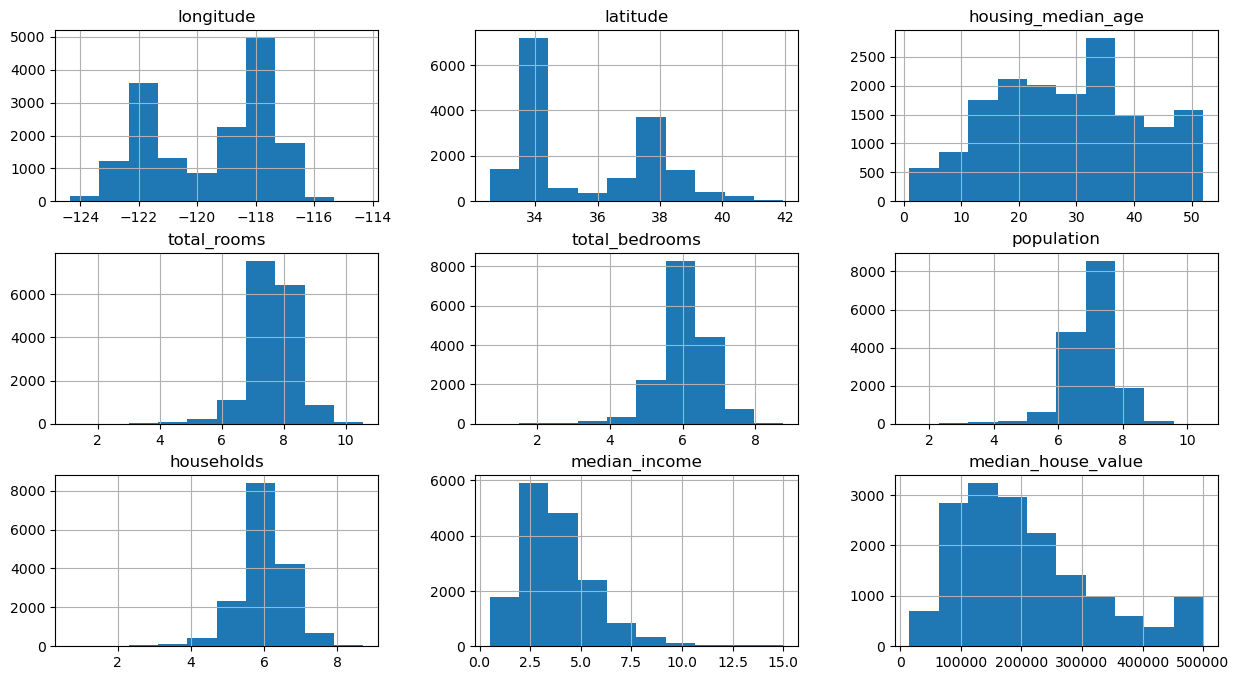

In [16]:
train_data.hist(figsize=(15,8))

In [17]:
train_data=train_data.join(pd.get_dummies(train_data.ocean_proximity)).drop(['ocean_proximity'],axis=1)

In [18]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
13696,-117.20,34.13,14.0,8.293800,6.568078,7.319865,6.501290,3.4138,126700.0,False,True,False,False,False
14787,-117.13,32.58,27.0,7.828835,6.423247,7.264030,6.357842,3.1645,156000.0,False,False,False,False,True
14053,-117.13,32.75,24.0,7.537963,6.253829,6.801283,6.182085,2.2264,112500.0,False,False,False,False,True
19141,-122.70,38.33,16.0,7.126891,5.493061,6.546785,5.468060,3.6369,158700.0,True,False,False,False,False
8150,-118.09,33.81,36.0,7.538495,5.780744,6.741701,5.786897,7.1937,254400.0,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20297,-119.22,34.15,32.0,8.056110,6.391917,8.157944,6.267201,2.7250,450000.0,False,False,False,False,True
2649,-124.10,40.50,42.0,7.775276,6.317165,7.170888,6.224558,1.7574,57500.0,True,False,False,False,False
10486,-117.68,33.48,15.0,7.488294,5.703782,6.590301,5.683580,5.0527,231400.0,True,False,False,False,False
20360,-118.94,34.17,16.0,8.228711,6.232448,7.350516,6.115892,6.3303,299400.0,True,False,False,False,False


<Axes: >

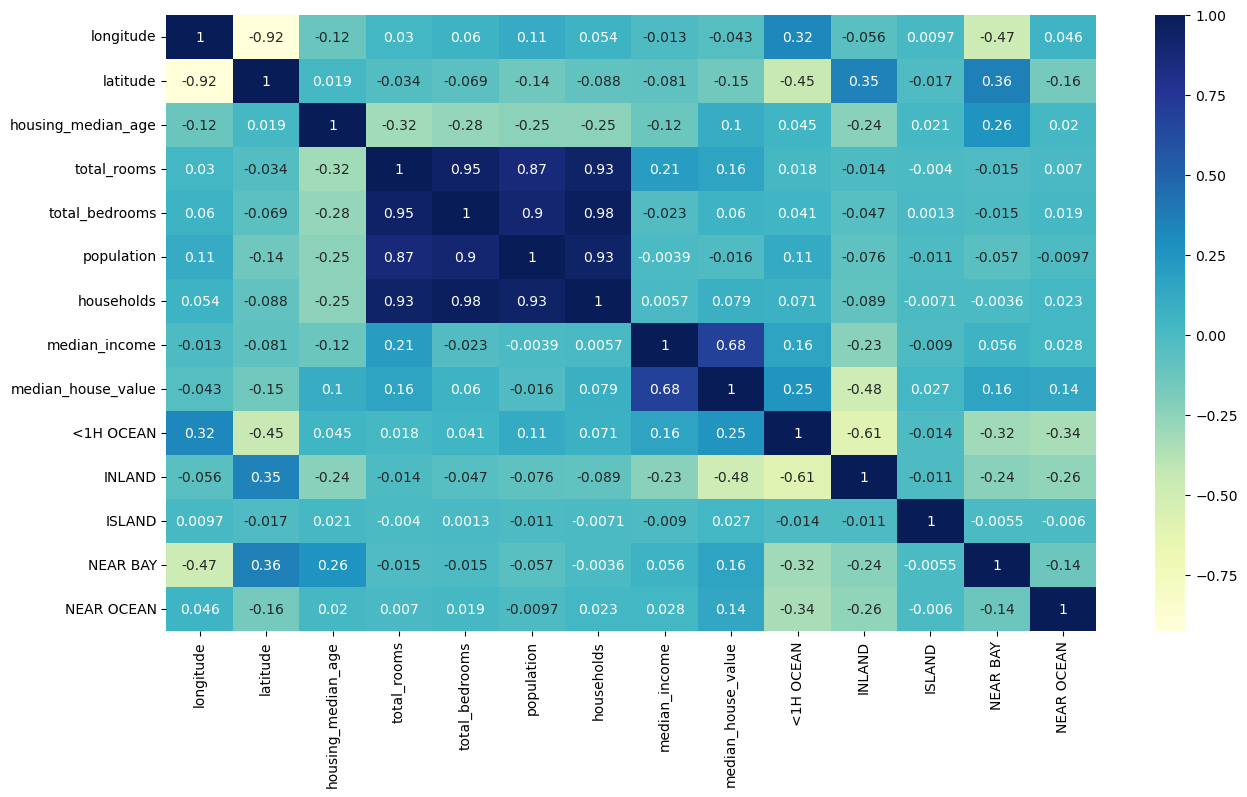

In [19]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap='YlGnBu')

<Axes: xlabel='latitude', ylabel='longitude'>

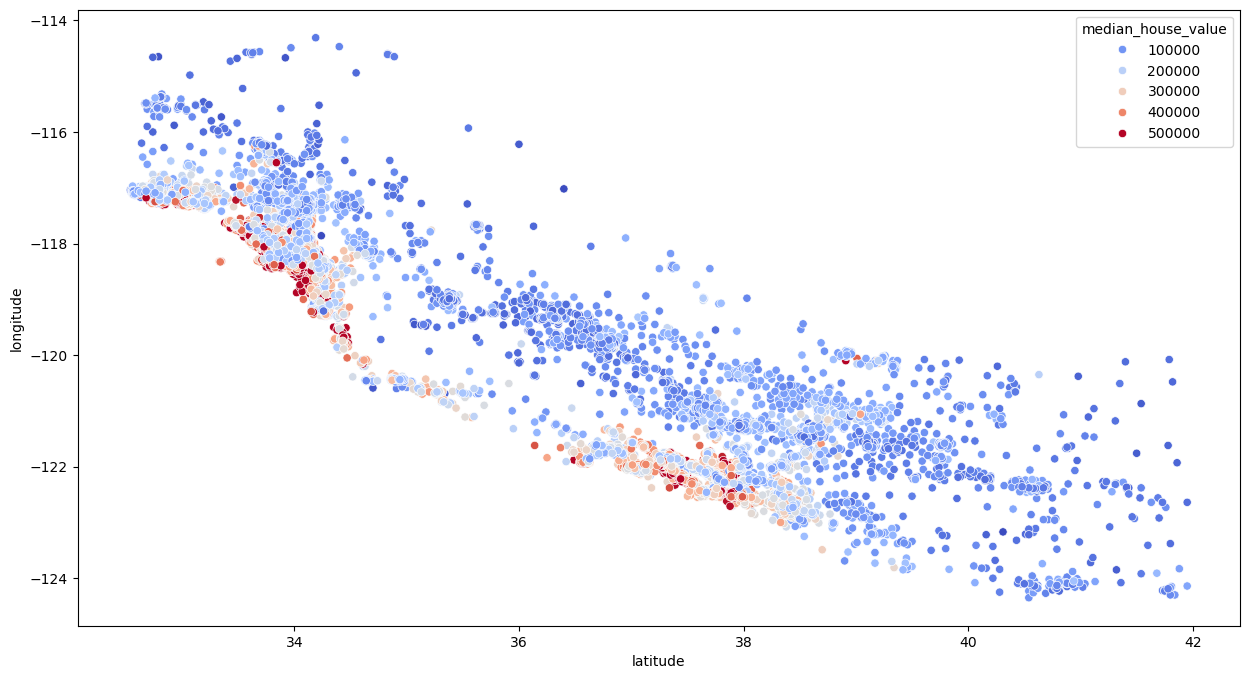

In [20]:
plt.figure(figsize=(15,8))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="coolwarm")
                

In [22]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households']

<Axes: >

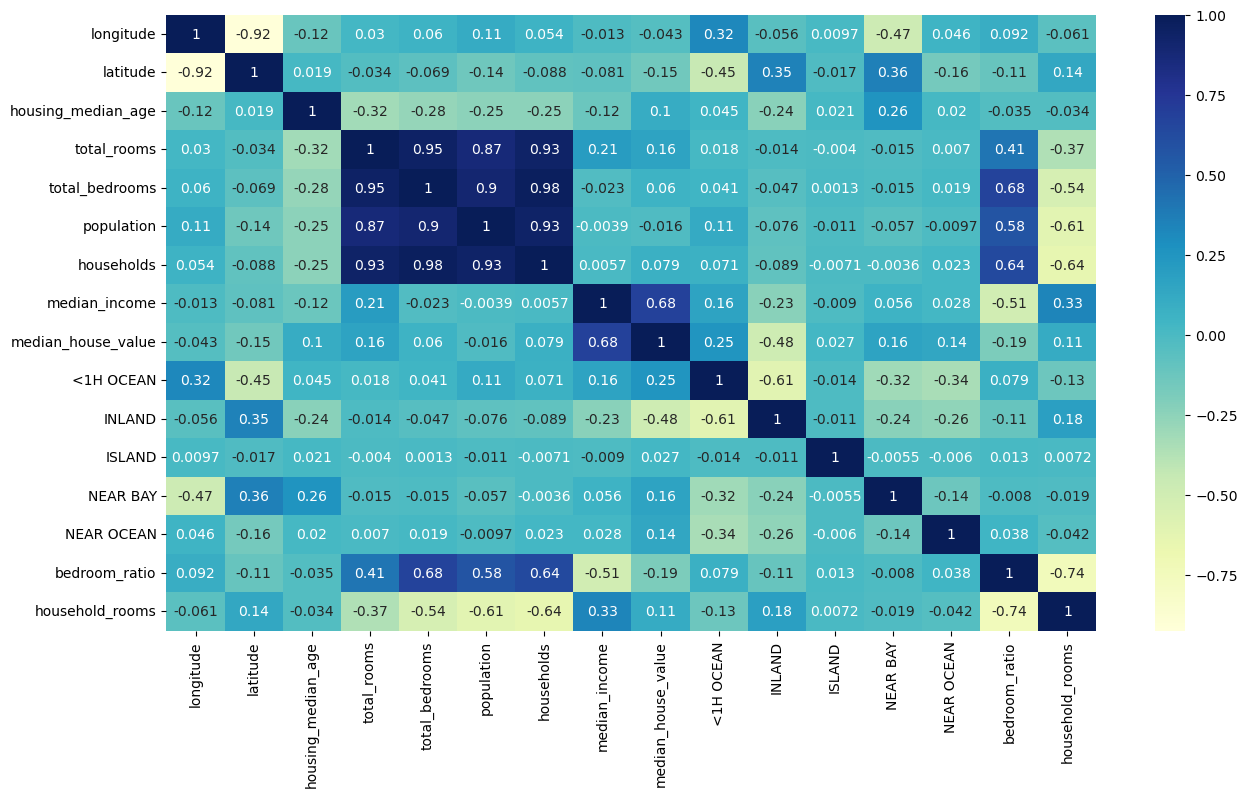

In [23]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap='YlGnBu')

In [24]:
from sklearn.linear_model import LinearRegression

x_train, y_train = train_data.drop(['median_house_value'], axis=1), train_data['median_house_value']

reg= LinearRegression()

reg.fit(x_train, y_train)

LinearRegression()

In [25]:
test_data= x_test.join(y_test)

test_data['total_rooms']=np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms']=np.log(test_data['total_bedrooms'] + 1)
test_data['population']=np.log(test_data['population'] + 1)
test_data['households']=np.log(test_data['households'] + 1)

test_data=test_data.join(pd.get_dummies(test_data.ocean_proximity)).drop(['ocean_proximity'],axis=1)

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']

In [26]:
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,household_rooms
1166,-121.56,39.51,47.0,6.970730,5.505332,6.403574,5.252273,1.3654,57900.0,False,True,False,False,False,0.789778,1.327183
9730,-121.74,36.79,16.0,8.253748,6.431331,7.495542,6.416732,4.3814,245300.0,True,False,False,False,False,0.779201,1.286285
14567,-117.20,32.83,36.0,6.993933,5.484797,6.436150,5.424950,2.5909,176000.0,False,False,False,False,True,0.784222,1.289216
5722,-118.23,34.18,43.0,7.443664,5.638355,6.645091,5.624018,6.2070,457400.0,True,False,False,False,False,0.757470,1.323549
9244,-120.05,36.98,16.0,8.217708,6.606650,7.809541,6.548219,2.5288,61800.0,False,True,False,False,False,0.803953,1.254953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13344,-117.64,34.05,32.0,7.029973,5.529429,7.229114,5.594711,3.0057,96900.0,False,True,False,False,False,0.786551,1.256539
10743,-117.92,33.61,37.0,7.126891,5.159055,5.978886,5.043425,10.3682,500001.0,True,False,False,False,False,0.723886,1.413105
11336,-117.97,33.76,27.0,7.446001,5.786897,6.944087,5.846439,4.0508,183900.0,True,False,False,False,False,0.777182,1.273596
452,-122.27,37.88,37.0,7.870930,6.526495,7.050123,6.424869,2.5200,277800.0,False,False,False,True,False,0.829190,1.225072


In [27]:
x_test, y_test = test_data.drop(['median_house_value'], axis=1), test_data['median_house_value']

In [28]:
reg.score(x_test, y_test)

0.6852528058542076

In [29]:
from sklearn.preprocessing import StandardScaler
scalar= StandardScaler()
x_train_s=scalar.fit_transform(x_train)
reg.fit(x_train_s, y_train)

LinearRegression()

In [30]:
x_test_s= scalar.transform(x_test)

In [31]:
reg.score(x_test_s, y_test)

0.6852528058542076

In [32]:
from sklearn.ensemble import RandomForestRegressor

forest= RandomForestRegressor()

forest.fit(x_train_s, y_train)

RandomForestRegressor()

In [33]:
forest.score(x_test_s, y_test)

0.8323372824183024

In [34]:
from sklearn.model_selection import GridSearchCV

forest= RandomForestRegressor()

param_grid = {
    "n_estimators": [30, 50, 100],
    "max_features": [8, 12, 20],
    "min_samples_split": [2, 4, 6, 8]
}


grid_search= GridSearchCV(forest, param_grid, cv=5,
                          scoring="neg_mean_squared_error",
                          return_train_score=True)

grid_search.fit(x_train_s, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_features': [8, 12, 20],
                         'min_samples_split': [2, 4, 6, 8],
                         'n_estimators': [30, 50, 100]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [42]:
best_forest = grid_search.best_estimator_

In [44]:
best_forest.score(x_test_s, y_test)

0.8315505262504688